# Bài thực hành số 1 — Làm quen với Gymnasium

**Học phần:** Học tăng cường — Reinforcement Learning

| | |
|---|---|
| Họ tên | Nguyen Quang Trung |
| MSSV | 22011211 |
| Lớp | K16_AI&RB |
| GitHub username | Qwup2112 |
| Repository | <https://github.com/Qwup2112/RL_22011211_NGUYEN_QUANG_TRUNG> |

Notebook này chạy lại toàn bộ 36 bài trong `Lab01/src/` và ghi nhận kết quả,
biểu đồ, nhận xét. Mỗi bài vẫn có file `.py` riêng trong `Lab01/src/`;
notebook chỉ import lại các hàm đó để tránh chép code hai lần.

> Toàn bộ code dùng **API Gymnasium mới**: `observation, info = env.reset()` và
> `observation, reward, terminated, truncated, info = env.step(action)`.
> Không dùng `import gym`, không dùng biến `done` của API cũ.

In [1]:
# Cho phep notebook import cac module trong Lab01/src/
import sys
from pathlib import Path

SRC_DIR = (Path.cwd().parent / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("src dir:", SRC_DIR)
print("exists :", SRC_DIR.exists())

src dir: D:\new_code\Lab01\src
exists : True


---
## PHẦN A — Cài đặt và khám phá Gymnasium

### Bài 1. Kiểm tra môi trường Python

Đọc phiên bản trực tiếp từ thư viện, không gõ tay số phiên bản.

In [2]:
import sys

import gymnasium as gym
import matplotlib
import numpy as np

print("Python version    :", ".".join(str(p) for p in sys.version_info[:3]))
print("Gymnasium version :", gym.__version__)
print("NumPy version     :", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

Python version    : 3.14.4
Gymnasium version : 1.3.0
NumPy version     : 2.5.2
Matplotlib version: 3.11.1


### Bài 2–4. Tạo CartPole, khám phá `action_space` và `observation_space`

In [3]:
from bai03 import count_actions

env = gym.make("CartPole-v1")

print("env              :", env)
print("env.unwrapped    :", env.unwrapped)
print("max_episode_steps:", env.spec.max_episode_steps)
print()

# Bai 3 - so action duoc xac dinh bang code, khong gan hang so
print("Action space      :", env.action_space)
print("Number of actions:", count_actions(env.action_space))
print()

# Bai 4 - shape / dtype / low / high cua observation space
obs_space = env.observation_space
print("Observation space :", obs_space)
print("Shape             :", obs_space.shape)
print("Data type (dtype) :", obs_space.dtype)
print("Lower bound (low) :", obs_space.low)
print("Upper bound (high):", obs_space.high)

env              : <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>
env.unwrapped    : <CartPoleEnv<CartPole-v1>>
max_episode_steps: 500

Action space      : Discrete(2)
Number of actions: 2

Observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Shape             : (4,)
Data type (dtype) : float32
Lower bound (low) : [-4.8               -inf -0.41887903        -inf]
Upper bound (high): [4.8               inf 0.41887903        inf]


### Bài 5. Quan sát trạng thái ban đầu

Ý nghĩa và kiểu dữ liệu của từng phần tử observation (CartPole-v1):

| Chỉ số | Ý nghĩa | Kiểu | Khoảng |
|--------|---------|------|--------|
| `observation[0]` | vị trí xe (cart position) | `numpy.float32` | −4.8 … 4.8 |
| `observation[1]` | vận tốc xe (cart velocity) | `numpy.float32` | −inf … inf |
| `observation[2]` | góc của pole, radian | `numpy.float32` | −0.418 … 0.418 |
| `observation[3]` | vận tốc góc của pole | `numpy.float32` | −inf … inf |

In [4]:
observation, info = env.reset(seed=42)

print("Observation:", observation)
print("Type       :", type(observation))
print("Shape      :", observation.shape)
print("Dtype      :", observation.dtype)
print("Info       :", info)

Observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Type       : <class 'numpy.ndarray'>
Shape      : (4,)
Dtype      : float32
Info       : {}


### Bài 6. Sinh 20 action ngẫu nhiên và thống kê tần suất

In [5]:
from collections import Counter

env.action_space.seed(42)
actions = [int(env.action_space.sample()) for _ in range(20)]

print("20 random actions:", actions)
print()

counter = Counter(actions)
for action in range(count_actions(env.action_space)):
    count = counter.get(action, 0)
    print(f"action {action}: {count:2d} lan  ({count / len(actions):.0%})")

env.close()   # Bai 2 - luon dong moi truong sau khi dung xong

20 random actions: [0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0]

action 0:  8 lan  (40%)
action 1: 12 lan  (60%)


---
## PHẦN B — Tương tác Agent–Environment

### Bài 7–8. Một bước tương tác và hàm `run_one_step()`

In [6]:
from bai08 import run_one_step

env = gym.make("CartPole-v1")
state_before, info = env.reset(seed=42)
env.action_space.seed(42)

action = env.action_space.sample()
state_after, reward, terminated, truncated, info = run_one_step(env, action)

print("State before action:", state_before)
print("Action             :", action)
print("State after action :", state_after)
print("Reward             :", reward)
print("Terminated         :", terminated)
print("Truncated          :", truncated)
print("Info               :", info)

State before action: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Action             : 0
State after action : [ 0.02727336 -0.20172954  0.03625453  0.32351476]
Reward             : 1.0
Terminated         : False
Truncated          : False
Info               : {}


### Bài 9–10. Chạy tối đa 20 bước và cộng dồn `total_reward`

In [7]:
observation, info = env.reset(seed=42)
env.action_space.seed(42)

total_reward = 0.0
episode_length = 0

print(" t  | action | reward | total_reward")
print("----+--------+--------+-------------")
for t in range(20):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    episode_length += 1
    print(f"{t:^4d}| {action:^7d}| {reward:^7.1f}| {total_reward:^12.1f}")

    if terminated or truncated:
        break

print()
print("Episode length:", episode_length)
print("Total reward  :", total_reward)

 t  | action | reward | total_reward
----+--------+--------+-------------
 0  |    0   |   1.0  |     1.0     
 1  |    1   |   1.0  |     2.0     
 2  |    1   |   1.0  |     3.0     
 3  |    0   |   1.0  |     4.0     
 4  |    0   |   1.0  |     5.0     
 5  |    1   |   1.0  |     6.0     
 6  |    0   |   1.0  |     7.0     
 7  |    1   |   1.0  |     8.0     
 8  |    0   |   1.0  |     9.0     
 9  |    0   |   1.0  |     10.0    
 10 |    1   |   1.0  |     11.0    
 11 |    1   |   1.0  |     12.0    
 12 |    1   |   1.0  |     13.0    
 13 |    1   |   1.0  |     14.0    
 14 |    1   |   1.0  |     15.0    
 15 |    1   |   1.0  |     16.0    
 16 |    1   |   1.0  |     17.0    
 17 |    0   |   1.0  |     18.0    
 18 |    1   |   1.0  |     19.0    
 19 |    0   |   1.0  |     20.0    

Episode length: 20
Total reward  : 20.0


### Bài 11–12. Random agent, và phiên bản không dùng biến `done`

`episode_finished = terminated or truncated` được **agent tự tạo**, không nhận
từ `env.step()`. Nhờ vậy vẫn biết được lý do episode kết thúc.

In [8]:
from bai12 import describe_ending, random_agent_no_done

env.reset(seed=42)
env.action_space.seed(42)

for episode in range(5):
    reward, length, terminated, truncated = random_agent_no_done(env)
    print(f"Episode {episode + 1}: reward={reward:6.1f}, length={length:3d}, "
          f"terminated={terminated}, truncated={truncated}  -> "
          f"{describe_ending(terminated, truncated)}")

env.close()

Episode 1: reward=  29.0, length= 29, terminated=True, truncated=False  -> Termination
Episode 2: reward=  17.0, length= 17, terminated=True, truncated=False  -> Termination
Episode 3: reward=  69.0, length= 69, terminated=True, truncated=False  -> Termination
Episode 4: reward=  15.0, length= 15, terminated=True, truncated=False  -> Termination
Episode 5: reward=  39.0, length= 39, terminated=True, truncated=False  -> Termination


---
## PHẦN C — Episode và thống kê thực nghiệm

### Bài 13–14. Chạy 10 và 100 episode

In [9]:
from bai11 import random_agent
from bai14 import run_random_episodes

# Bai 13 - bang ket qua cua 10 episode
env = gym.make("CartPole-v1")
env.reset(seed=42)
env.action_space.seed(42)

print("Episode | Reward | Length")
print("--------+--------+-------")
for episode in range(1, 11):
    reward, length = random_agent(env)
    print(f"{episode:^8d}| {reward:^7.1f}| {length:^6d}")
env.close()

# Bai 14 - 100 episode, khong in tung timestep
episode_rewards, episode_lengths = run_random_episodes(n_episodes=100, seed=42)
print()
print("len(episode_rewards) =", len(episode_rewards))
print("10 reward dau tien   :", episode_rewards[:10])

Episode | Reward | Length
--------+--------+-------
   1    |  29.0  |   29  
   2    |  17.0  |   17  
   3    |  69.0  |   69  
   4    |  15.0  |   15  
   5    |  39.0  |   39  
   6    |  25.0  |   25  
   7    |  14.0  |   14  
   8    |  23.0  |   23  
   9    |  28.0  |   28  
   10   |  42.0  |   42  

len(episode_rewards) = 100
10 reward dau tien   : [29.0, 17.0, 69.0, 15.0, 39.0, 25.0, 14.0, 23.0, 28.0, 42.0]


### Bài 15–16. Thống kê reward và tìm episode tốt nhất

Bài 16 dùng `np.argmax` trên mảng đã lưu — **không chạy lại môi trường**.

In [10]:
from bai15 import compute_statistics
from bai16 import find_best_episode

stats = compute_statistics(episode_rewards)
print(f"Mean reward : {stats['mean']:.2f}")
print(f"Min reward  : {stats['min']:.2f}")
print(f"Max reward  : {stats['max']:.2f}")
print(f"Std reward  : {stats['std']:.2f}")

best = find_best_episode(episode_rewards, episode_lengths)
print()
print(f"Best episode: #{best['episode']}, reward = {best['reward']:.1f}, "
      f"length = {best['length']}")

Mean reward : 22.99
Min reward  : 8.00
Max reward  : 73.00
Std reward  : 12.30

Best episode: #81, reward = 73.0, length = 73


### Bài 17–18. Biểu đồ reward và moving average

Hàm `moving_average()` được tự cài đặt bằng kỹ thuật cửa sổ trượt
(không dùng `pandas.rolling`).

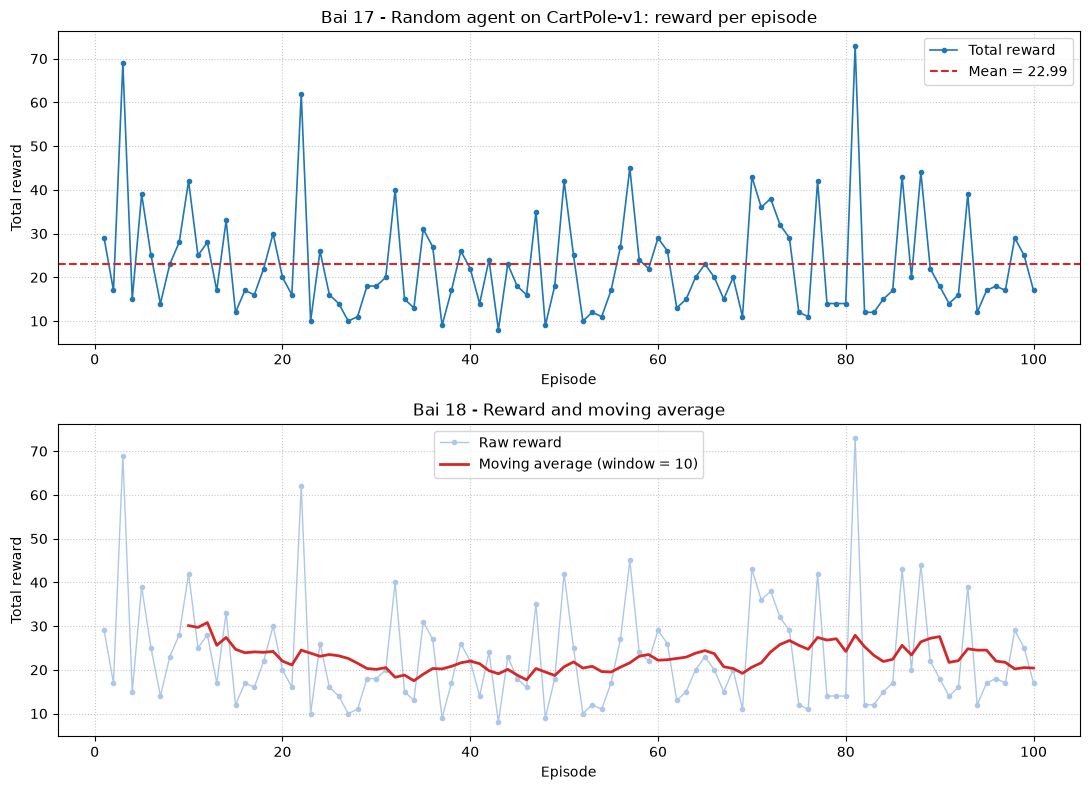

In [11]:
# bai18 dat backend "Agg" khi import (de chay duoc tu terminal),
# nen phai import truoc roi moi bat lai che do inline cho notebook.
from bai18 import moving_average

%matplotlib inline
import matplotlib.pyplot as plt

window_size = 10
smoothed = moving_average(episode_rewards, window_size)
episodes = np.arange(1, len(episode_rewards) + 1)
smoothed_x = np.arange(window_size, len(episode_rewards) + 1)

figure, axes = plt.subplots(2, 1, figsize=(11, 8))

axes[0].plot(episodes, episode_rewards, marker="o", markersize=3,
             linewidth=1.2, color="#1f77b4", label="Total reward")
axes[0].axhline(np.mean(episode_rewards), color="#d62728", linestyle="--",
                label=f"Mean = {np.mean(episode_rewards):.2f}")
axes[0].set_title("Bai 17 - Random agent on CartPole-v1: reward per episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].grid(True, linestyle=":", alpha=0.7)
axes[0].legend()

axes[1].plot(episodes, episode_rewards, color="#aec7e8", linewidth=1.0,
             marker="o", markersize=3, label="Raw reward")
axes[1].plot(smoothed_x, smoothed, color="#d62728", linewidth=2.0,
             label=f"Moving average (window = {window_size})")
axes[1].set_title("Bai 18 - Reward and moving average")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Total reward")
axes[1].grid(True, linestyle=":", alpha=0.7)
axes[1].legend()

figure.tight_layout()
plt.show()

**Nhận xét.** Đường reward thô dao động rất mạnh (8 → 73), moving average phẳng
quanh mức ~21. Điều đó xác nhận random agent **không học**: không có xu hướng
đi lên theo thời gian, chỉ có nhiễu.

---
## PHẦN D — Random seed và khả năng tái lập

### Bài 19–21. Seed cho môi trường và cho action space

In [12]:
from bai19 import collect_initial_observations
from bai21 import sample_action_sequence

# Bai 19 - 10 environment doc lap, cung seed=42
observations = collect_initial_observations(seed=42, n_environments=10)
for index, obs in enumerate(observations[:3], start=1):
    print(f"env {index}: {obs}")
print("...")
print("All 10 observations identical:",
      all(np.array_equal(observations[0], obs) for obs in observations))

# Bai 21 - seed rieng cho action space
first_run = sample_action_sequence(123)
second_run = sample_action_sequence(123)
print()
print("Run 1:", first_run)
print("Run 2:", second_run)
print("Identical action sequences:", first_run == second_run)

env 1: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
env 2: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
env 3: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
...
All 10 observations identical: True

Run 1: [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Run 2: [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Identical action sequences: True


**Kết luận (Bài 19).** Cả 10 environment độc lập đều trả về đúng một
observation ban đầu khi `reset(seed=42)`, vì seed quyết định hoàn toàn bộ sinh
số ngẫu nhiên của môi trường. Nhờ vậy thí nghiệm RL tái lập được chính xác.

Lưu ý `env.reset(seed=...)` và `env.action_space.seed(...)` là **hai bộ sinh số
khác nhau**: cái đầu quyết định trạng thái khởi tạo, cái sau quyết định chuỗi
action ngẫu nhiên.

### Bài 20 & 22. So sánh nhiều seed

In [13]:
from bai22 import experiment

print(" Seed | Mean   | Std    | Min    | Max")
print("------+--------+--------+--------+--------")
for seed in [0, 42, 100, 2024, 31337, 7]:
    result = experiment(seed, n_episodes=50)
    print(f"{result['seed']:^6d}| {result['mean_reward']:^7.2f}| "
          f"{result['std_reward']:^7.2f}| {result['min_reward']:^7.2f}| "
          f"{result['max_reward']:^7.2f}")

 Seed | Mean   | Std    | Min    | Max
------+--------+--------+--------+--------
  0   |  21.46 |  10.67 |  10.00 |  72.00 
  42  |  22.98 |  12.28 |  8.00  |  69.00 
 100  |  20.46 |  12.79 |  8.00  |  74.00 
 2024 |  19.84 |  11.98 |  9.00  |  89.00 
31337 |  25.76 |  16.03 |  10.00 |  98.00 
  7   |  22.08 |  10.90 |  8.00  |  58.00 


**Nhận xét.** Mean reward của cùng một random agent dao động khoảng ±2 giữa các
seed. Vì vậy so sánh hai agent chỉ dựa trên **một** seed là không đủ tin cậy —
phải chạy nhiều episode và nên báo cáo cả std.

---
## PHẦN E — Làm quen môi trường rời rạc FrozenLake

### Bài 23–25. Không gian state/action, hiển thị bản đồ, ánh xạ action

In [14]:
from bai25 import ACTION_NAMES, discover_action_meaning

lake = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
observation, info = lake.reset(seed=42)

print("Observation space:", lake.observation_space)
print("Action space     :", lake.action_space)
print("Number of states :", int(lake.observation_space.n))
print("Number of actions:", int(lake.action_space.n))
print()
print(lake.render())

# Bai 25 - xac dinh y nghia action bang thi nghiem, khong tin vao tri nho
discovered = discover_action_meaning(lake, start_state=9)
print("Ket qua thi nghiem tu o so 9:")
for action, direction in discovered.items():
    print(f"  Action {action} -> {direction}")
print()
print("ACTION_NAMES =", ACTION_NAMES)

Observation space: Discrete(16)
Action space     : Discrete(4)
Number of states : 16
Number of actions: 4


SFFF
FHFH
FFFH
HFFG

Ket qua thi nghiem tu o so 9:
  Action 0 -> LEFT
  Action 1 -> DOWN
  Action 2 -> RIGHT
  Action 3 -> UP

ACTION_NAMES = {0: 'LEFT', 1: 'DOWN', 2: 'RIGHT', 3: 'UP'}


### Bài 26. Điều khiển FrozenLake bằng chuỗi action

Bản đồ 4×4 mặc định và đường đi đã chọn: `0 → 4 → 8 → 9 → 10 → 14 → 15`.

```
S F F F      0  1  2  3
F H F H      4  5  6  7
F F F H      8  9 10 11
H F F G     12 13 14 15
```

In [15]:
from bai26 import actions as planned_actions

observation, info = lake.reset(seed=42)
total_reward = 0.0

for step_index, action in enumerate(planned_actions, start=1):
    observation, reward, terminated, truncated, info = lake.step(action)
    total_reward += float(reward)
    row, col = divmod(int(observation), 4)
    print(f"Step {step_index}: action={action} ({ACTION_NAMES[action]:>5s}) -> "
          f"state={observation:2d} (row {row}, col {col}), reward={reward}, "
          f"terminated={terminated}")

print()
print("Total reward:", total_reward)
print("Reached the Goal:", total_reward > 0)
lake.close()

Step 1: action=1 ( DOWN) -> state= 4 (row 1, col 0), reward=0, terminated=False
Step 2: action=1 ( DOWN) -> state= 8 (row 2, col 0), reward=0, terminated=False
Step 3: action=2 (RIGHT) -> state= 9 (row 2, col 1), reward=0, terminated=False
Step 4: action=2 (RIGHT) -> state=10 (row 2, col 2), reward=0, terminated=False
Step 5: action=1 ( DOWN) -> state=14 (row 3, col 2), reward=0, terminated=False
Step 6: action=2 (RIGHT) -> state=15 (row 3, col 3), reward=1, terminated=True

Total reward: 1.0
Reached the Goal: True


### Bài 27–28. Success rate và so sánh deterministic / stochastic

In [16]:
from bai28 import evaluate as evaluate_frozenlake

results_fl = [
    evaluate_frozenlake(False, "random", n_episodes=500),
    evaluate_frozenlake(True, "random", n_episodes=500),
    evaluate_frozenlake(False, "planned", n_episodes=500),
    evaluate_frozenlake(True, "planned", n_episodes=500),
]

print("Policy  | is_slippery | Success | Success rate | Avg reward | Avg length")
print("--------+-------------+---------+--------------+------------+-----------")
for result in results_fl:
    print(f"{result['policy']:<8s}| {str(result['is_slippery']):^12s}| "
          f"{result['success']:^8d}| {result['success_rate']:^13.4f}| "
          f"{result['average_reward']:^11.4f}| {result['average_length']:^10.2f}")

Policy  | is_slippery | Success | Success rate | Avg reward | Avg length
--------+-------------+---------+--------------+------------+-----------
random  |    False    |    7    |    0.0140    |   0.0140   |    7.70   
random  |     True    |    10   |    0.0200    |   0.0200   |    7.99   
planned |    False    |   500   |    1.0000    |   1.0000   |    6.00   
planned |     True    |    16   |    0.0320    |   0.0320   |    5.06   


**Kết luận (Bài 28).**

1. `is_slippery=False`: môi trường **tất định**, chuỗi action tính sẵn thắng
   100% và chỉ mất 6 bước.
2. `is_slippery=True`: agent chỉ đi đúng hướng với xác suất 1/3, hai hướng
   vuông góc mỗi hướng 1/3. Cùng chuỗi action đó tụt xuống chỉ còn ~3%.
3. Với **random policy**, hai cấu hình gần như không khác nhau (1.4% vs 2.0% —
   chỉ là nhiễu thống kê): random policy vốn đã đi lang thang nên môi trường
   trộn thêm cũng không làm nó tệ hơn. Không thể dùng random policy để đánh giá
   độ khó của một môi trường.
4. Tính ngẫu nhiên của transition khiến agent **không thể chỉ nhớ đường đi** mà
   phải học một policy theo *trạng thái*, chịu được nhiễu — đây chính là lý do
   cần đến các thuật toán RL.

---
## PHẦN F — Policy và cải thiện agent

### Bài 29–32. Từ random policy tới heuristic hai thành phần

- **Bài 29:** mọi chỗ gọi `env.action_space.sample()` trong agent được thay bằng
  `policy(observation)`.
- **Bài 30:** `always_left_policy` / `always_right_policy`.
- **Bài 31:** `angle_based_policy` — dùng `observation[2]` (góc của pole).
- **Bài 32:** policy cải tiến — dùng thêm `observation[3]` (vận tốc góc) để dự
  đoán góc sắp tới: `predicted_angle = angle + 0.5 * angular_velocity`.

In [17]:
from bai30 import always_left_policy, always_right_policy
from bai31 import angle_based_policy
from bai32 import improved_policy


def evaluate_on_cartpole(policy, n_episodes=100, seed=42):
    env = gym.make("CartPole-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)

    rewards = []
    for _ in range(n_episodes):
        observation, info = env.reset()
        total = 0.0
        while True:
            observation, reward, terminated, truncated, info = env.step(policy(observation))
            total += float(reward)
            if terminated or truncated:
                break
        rewards.append(total)

    env.close()
    return np.array(rewards)


cartpole_env = gym.make("CartPole-v1")
cartpole_env.action_space.seed(42)
policies = {
    "random": lambda observation: cartpole_env.action_space.sample(),
    "always_left": always_left_policy,
    "always_right": always_right_policy,
    "angle_based": angle_based_policy,
    "improved": improved_policy,
}

print("Policy       | Mean   | Std   | Min   | Max")
print("-------------+--------+-------+-------+-------")
means = {}
for name, policy in policies.items():
    rewards = evaluate_on_cartpole(policy, n_episodes=100)
    means[name] = float(rewards.mean())
    print(f"{name:<13s}| {rewards.mean():^7.2f}| {rewards.std():^6.2f}| "
          f"{rewards.min():^6.1f}| {rewards.max():^6.1f}")

cartpole_env.close()
print()
print(f"Muc tieu Bai 32: mean(improved) > mean(random) -> "
      f"{means['improved']:.2f} > {means['random']:.2f} = "
      f"{means['improved'] > means['random']}")

Policy       | Mean   | Std   | Min   | Max
-------------+--------+-------+-------+-------
random       |  22.99 | 12.30 |  8.0  |  73.0 
always_left  |  9.46  |  0.74 |  8.0  |  11.0 
always_right |  9.27  |  0.73 |  8.0  |  11.0 
angle_based  |  42.04 |  9.27 |  24.0 |  72.0 


improved     | 500.00 |  0.00 | 500.0 | 500.0 

Muc tieu Bai 32: mean(improved) > mean(random) -> 500.00 > 22.99 = True


**Nhận xét.**

- Hai policy cố định (`always_left`, `always_right`) tệ nhất (~9 điểm): xe luôn
  bị đẩy về một phía nên cột ngã gần như ngay lập tức.
- Random policy (~22 điểm) tốt hơn *một cách tình cờ*: nó đổi hướng liên tục.
- `angle_based` (~42 điểm) là policy đầu tiên thực sự **dùng observation**.
- `improved` đạt trần 500 điểm vì phản ứng **sớm hơn**: khi vận tốc góc lớn thì
  đẩy xe trước, không đợi đến lúc góc đã lệch.

---
## PHẦN G — Tổ chức code như một thí nghiệm RL

### Bài 33–34. `run_episode()` và `evaluate_policy()` tổng quát

`run_episode()` không phụ thuộc riêng CartPole — dùng được cho mọi môi trường
Gymnasium.

In [18]:
from bai33 import make_random_policy, run_episode
from bai34 import evaluate_policy

print("Env name       | Reward | Length | Terminated | Truncated")
print("---------------+--------+--------+------------+----------")
for env_name in ["CartPole-v1", "FrozenLake-v1", "MountainCar-v0"]:
    demo_env = gym.make(env_name)
    result = run_episode(demo_env, make_random_policy(env_name, seed=42),
                         seed=42, max_steps=1000)
    print(f"{env_name:<15s}| {result['reward']:^7.1f}| {result['length']:^7d}| "
          f"{str(result['terminated']):^11s}| {str(result['truncated']):^9s}")
    demo_env.close()

print()
evaluation = evaluate_policy("CartPole-v1", make_random_policy("CartPole-v1", 42),
                             n_episodes=100, seed=42)
print("evaluate_policy() tren random policy, 100 episode:")
for key in ["mean_reward", "std_reward", "min_reward", "max_reward", "mean_length"]:
    print(f"  {key:<12s}: {evaluation[key]:.2f}")

Env name       | Reward | Length | Terminated | Truncated
---------------+--------+--------+------------+----------
CartPole-v1    |  30.0  |   30   |    True    |   False  
FrozenLake-v1  |   0.0  |   20   |    True    |   False  
MountainCar-v0 | -200.0 |   200  |    False   |   True   

evaluate_policy() tren random policy, 100 episode:
  mean_reward : 22.82
  std_reward  : 11.61
  min_reward  : 8.00
  max_reward  : 73.00
  mean_length : 22.82


`MountainCar-v0` là ví dụ rõ nhất cho `truncated`: random policy không bao giờ
lên được tới đỉnh nên episode luôn bị **cắt ngang** ở bước thứ 200
(`terminated=False`, `truncated=True`).

### Bài 35. So sánh ba agent (500 episode mỗi agent)

Agent       | Mean reward |  Std   |  Min   |  Max   | Mean length
------------+-------------+--------+--------+--------+------------
Random      |    21.59    |  10.42 |   8.0  |  73.0  |    21.59   
Angle-based |    42.21    |  9.03  |  24.0  |  72.0  |    42.21   
Improved    |    500.00   |  0.00  |  500.0 |  500.0 |   500.00   


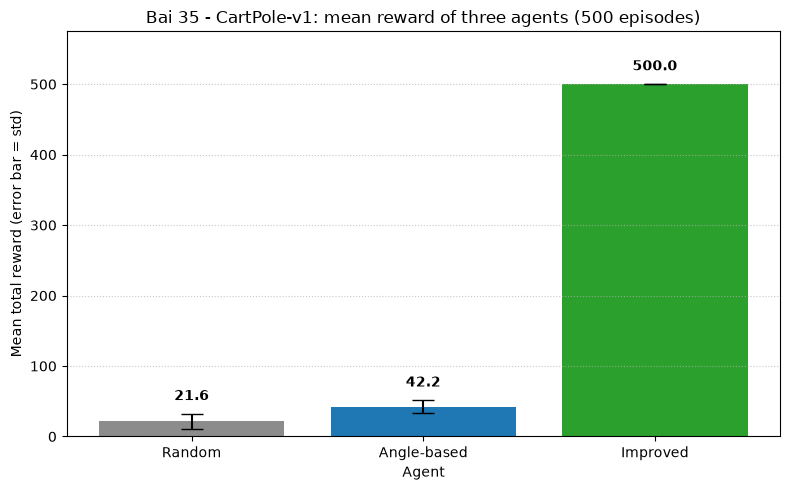

In [19]:
%matplotlib inline

env_name = "CartPole-v1"
n_episodes = 500
seed = 42

agents = {
    "Random": make_random_policy(env_name, seed=seed),
    "Angle-based": angle_based_policy,
    "Improved": improved_policy,
}

comparison = {name: evaluate_policy(env_name, policy, n_episodes=n_episodes, seed=seed)
              for name, policy in agents.items()}

print("Agent       | Mean reward |  Std   |  Min   |  Max   | Mean length")
print("------------+-------------+--------+--------+--------+------------")
for name, result in comparison.items():
    print(f"{name:<12s}| {result['mean_reward']:^12.2f}| {result['std_reward']:^7.2f}| "
          f"{result['min_reward']:^7.1f}| {result['max_reward']:^7.1f}| "
          f"{result['mean_length']:^11.2f}")

names = list(comparison)
values = [comparison[name]["mean_reward"] for name in names]
errors = [comparison[name]["std_reward"] for name in names]

figure, axes = plt.subplots(figsize=(8, 5))
bars = axes.bar(names, values, yerr=errors, capsize=8,
                color=["#8c8c8c", "#1f77b4", "#2ca02c"])
top = max(value + error for value, error in zip(values, errors))
for bar, value, error in zip(bars, values, errors):
    axes.text(bar.get_x() + bar.get_width() / 2, value + error + 0.03 * top,
              f"{value:.1f}", ha="center", va="bottom", fontweight="bold")
axes.set_ylim(0, top * 1.15)
axes.set_title("Bai 35 - CartPole-v1: mean reward of three agents (500 episodes)")
axes.set_xlabel("Agent")
axes.set_ylabel("Mean total reward (error bar = std)")
axes.grid(True, axis="y", linestyle=":", alpha=0.7)
figure.tight_layout()
plt.show()

**Nhận xét Bài 35 (5–10 dòng).**

1. Random policy chỉ trụ được ~21.6 bước vì bỏ qua hoàn toàn observation.
2. Angle-based đạt ~42.2 — chỉ cần dùng `observation[2]` là reward đã gấp đôi.
3. Improved đạt 500.0: thêm `observation[3]` giúp phản ứng trước khi góc kịp lớn.
4. Std giảm từ 10.4 xuống 0.0: luật cải tiến ổn định với **mọi** trạng thái khởi
   tạo, không phải may mắn ở vài episode.
5. Random kết thúc bằng `terminated` 500/500 lần (cột ngã), Improved kết thúc
   bằng `truncated` 500/500 lần — chạm giới hạn 500 bước, kết quả tốt nhất có
   thể của `CartPole-v1`.
6. Cả ba agent đều **không học**: không tham số nào được cập nhật từ reward.
7. Chỉ cần dùng thêm thông tin từ observation là hiệu quả đã tăng 23 lần — và đó
   chính là việc mà một policy học được sẽ tự làm.

### Bài 36. Mini-project — Agent–Environment hoàn chỉnh

Chương trình đầy đủ nằm ở `src/bai36.py` với các hàm
`create_environment()`, `policy()`, `run_episode()`, `evaluate_policy()`,
`plot_results()`, `main()`.

In [20]:
import bai36

bai36.main()

MINI-PROJECT - CartPole-v1 - 500 episodes - seed 42

--- Agent 1: random policy ---
  Episodes      : 500
  Mean reward   : 21.64
  Std reward    : 10.58
  Min reward    : 8.00
  Max reward    : 73.00
  Mean length   : 21.64
  Best episode  : #81 (reward 73.0, length 73)
  Worst episode : #43 (reward 8.0, length 8)
  terminated=500, truncated=0



--- Agent 2: heuristic policy (angle + angular velocity) ---
  Episodes      : 500
  Mean reward   : 500.00
  Std reward    : 0.00
  Min reward    : 500.00
  Max reward    : 500.00
  Mean length   : 500.00
  Best episode  : #1 (reward 500.0, length 500)
  Worst episode : #1 (reward 500.0, length 500)
  terminated=0, truncated=500



Episode data saved to : D:\new_code\Lab01\data\mini_project_episodes.csv
Figure saved to       : D:\new_code\Lab01\figures\mini_project_rewards.png
Figure saved to       : D:\new_code\Lab01\figures\mini_project_moving_average.png

CONCLUSION
--------------------------------------------------------------------
1. The heuristic agent gains +478.36 reward per episode over
   the random agent (23.1x better mean reward).
2. The random agent ends with terminated=True in 500/500 episodes (the pole falls)
   after 21.6 steps on average, while the heuristic agent ends
   with truncated=True in 500/500 episodes: it hits the 500-step
   TimeLimit, which is the best possible outcome on CartPole-v1.
3. Std goes from 10.58 (random) to 0.00 (heuristic): the rule works for
   every random initial state produced by reset(), it is not luck.
4. The moving average curve is flat: neither agent learns, they only
   apply a fixed rule. A real RL algorithm would show an upward trend.
5. Seeding makes the whol

mini_project_rewards.png


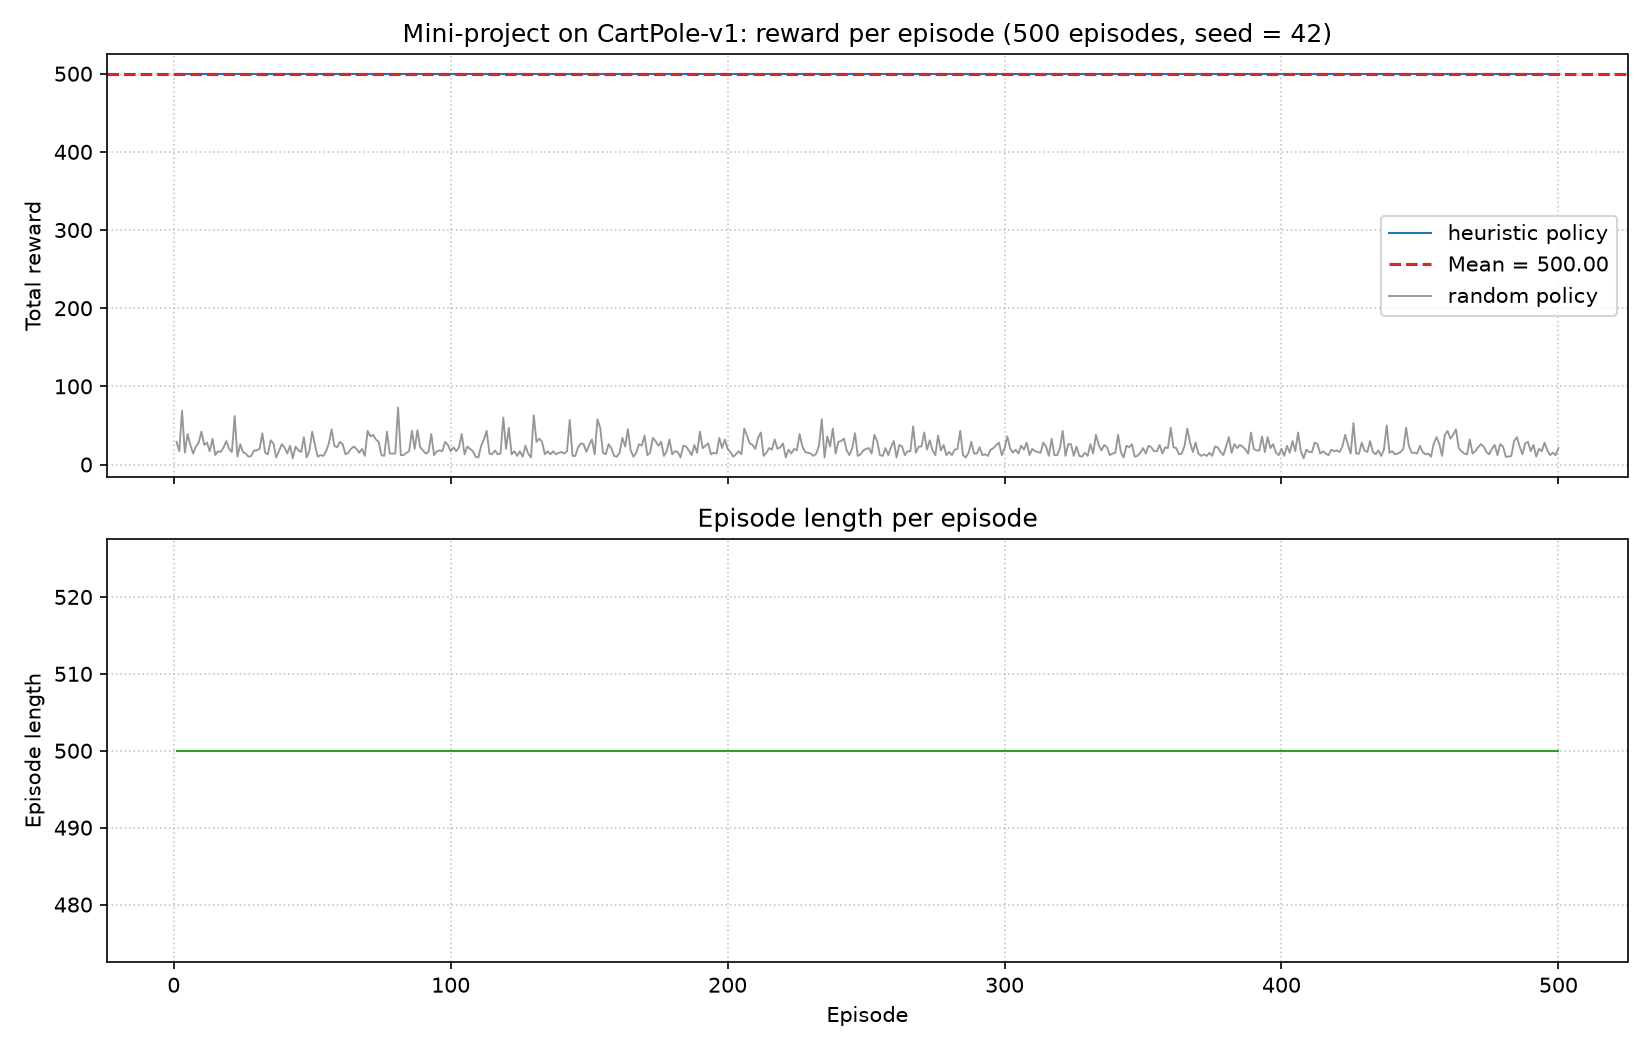

mini_project_moving_average.png


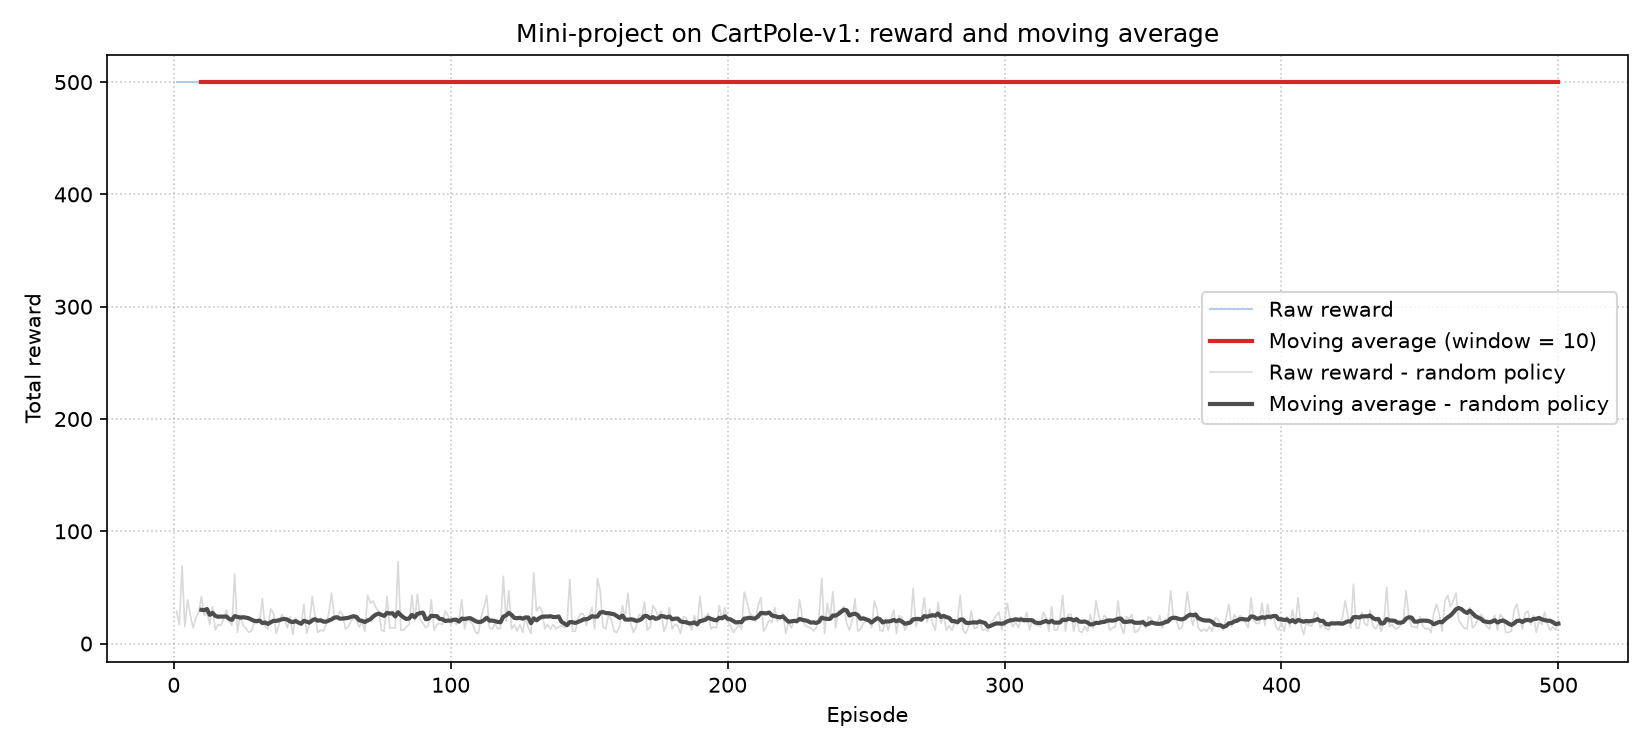

In [21]:
%matplotlib inline
from IPython.display import Image, display

FIGURES = Path.cwd().parent / "figures"
for name in ["mini_project_rewards.png", "mini_project_moving_average.png"]:
    print(name)
    display(Image(filename=str(FIGURES / name)))

---
## Mục 8 — Chuyển code Gym cũ sang Gymnasium

Code cũ (không được dùng):

```python
import gym

env = gym.make("CartPole-v0")
observation = env.reset()

for t in range(1000):
    env.render()
    action = env.action_space.sample()
    observation, reward, done, info = env.step(action)
    if done:
        break
```

Bản viết lại đầy đủ nằm ở `src/migration_gym_to_gymnasium.py`.

In [22]:
import migration_gym_to_gymnasium as migration

migration.run_migrated_program()

Episode ended at step t=29 -> Termination
  terminated = True
  truncated  = False
Total reward: 30.0


**Giải thích bắt buộc.**

- **`terminated` có ý nghĩa gì?** `terminated = True` khi episode kết thúc theo
  đúng *bản chất* của bài toán: agent đi vào một trạng thái kết thúc (terminal
  state). CartPole: cột nghiêng quá 12 độ hoặc xe chạy khỏi ray. FrozenLake: rơi
  xuống hố hoặc tới Goal. Sau trạng thái này không còn tương lai nào để tính,
  giá trị của trạng thái kế tiếp bằng 0.
- **`truncated` có ý nghĩa gì?** `truncated = True` khi episode bị **cắt ngang**
  bởi một giới hạn *bên ngoài* bài toán — thường là số bước tối đa (wrapper
  `TimeLimit`; `CartPole-v1` là 500 bước). Bản thân bài toán chưa kết thúc, agent
  vẫn còn có thể đi tiếp nếu được phép, nên trạng thái cuối vẫn còn giá trị
  tương lai.
- **Vì sao không nên dùng `done` của API cũ?** API cũ gộp hai trường hợp trên vào
  một biến duy nhất nên agent không phân biệt được "kết thúc thật sự" với "hết
  giờ". Khi học giá trị (Q-Learning, DQN...) hai trường hợp phải xử lý **khác
  nhau**:
  - `terminated`: `target = reward`
  - `truncated`: `target = reward + gamma * V(next_state)` (vẫn bootstrap)

  Dùng chung `done` sẽ bootstrap sai ở các episode bị cắt ngang, làm lệch giá trị
  học được. Đó là lý do Gymnasium tách `done` thành `terminated` và `truncated`.

---
## Mục 10 — Trả lời câu hỏi

**1. Agent là gì?**
Là thực thể ra quyết định: ở mỗi bước nó nhận observation, chọn một action và
nhận lại reward. Trong bài này agent chính là hàm `policy()` cộng với vòng lặp
tương tác; agent *không* phải là môi trường và không biết trước quy luật của môi
trường.

**2. Environment là gì?**
Là toàn bộ phần còn lại của thế giới mà agent tác động vào: nó giữ trạng thái
thật, nhận action và trả về observation kế tiếp + reward + `terminated` +
`truncated`. Ở đây environment là đối tượng `gym.make("CartPole-v1")`.

**3. Observation khác action như thế nào?**
Observation là thông tin đi **từ môi trường tới agent** (mô tả trạng thái, ví dụ
4 số thực của CartPole). Action là quyết định đi **từ agent tới môi trường** (ví
dụ 0 hoặc 1). Observation là đầu vào của policy, action là đầu ra.

**4. Reward dùng để làm gì?**
Là tín hiệu vô hướng cho biết bước vừa rồi *tốt* đến đâu; nó định nghĩa mục tiêu
của bài toán. Agent tìm policy tối đa hóa tổng reward, chứ không tối đa hóa
reward của riêng một bước. CartPole cho +1 mỗi bước còn trụ được; FrozenLake chỉ
cho +1 khi tới Goal.

**5. Episode là gì?**
Một lượt tương tác trọn vẹn từ `reset()` cho tới khi `terminated or truncated`
bằng `True`. Trong bài này một episode CartPole dài từ 8 tới 500 bước.

**6. Policy là gì?**
Quy tắc ánh xạ observation sang action, ký hiệu pi(a|s). Có thể tất định
(`improved_policy`) hoặc ngẫu nhiên (random policy). Toàn bộ "trí tuệ" của agent
nằm trong policy.

**7. `action_space` thể hiện điều gì?**
Tập tất cả action hợp lệ và kiểu của chúng. CartPole: `Discrete(2)` — hai action
rời rạc 0 và 1. FrozenLake: `Discrete(4)`. Nó còn cung cấp `.sample()` và
`.seed()`.

**8. `observation_space` thể hiện điều gì?**
Tập tất cả observation hợp lệ: kiểu, shape, dtype và giới hạn. CartPole:
`Box(4,)` float32 với `low`/`high`. FrozenLake: `Discrete(16)` — 16 ô của lưới.

**9. `reset()` được gọi khi nào?**
Ở đầu mỗi episode, trước lần `step()` đầu tiên, để đưa môi trường về trạng thái
khởi tạo. Trả về `(observation, info)`. Truyền `seed=` ở lần reset đầu tiên để
thí nghiệm tái lập được — **không** seed lại ở mọi episode, nếu không cả loạt
episode sẽ giống hệt nhau.

**10. `step(action)` thực hiện việc gì?**
Đưa một action vào môi trường, cho môi trường tiến một timestep và trả về 5 giá
trị: `observation, reward, terminated, truncated, info` — tức là chuyển
`S_t --A_t--> S_(t+1), R_(t+1)`.

**11. `terminated` và `truncated` khác nhau thế nào?**
`terminated` = kết thúc **tự nhiên** theo luật bài toán (cột ngã, rơi hố, tới
Goal) — trạng thái kế tiếp không còn giá trị. `truncated` = bị cắt ngang bởi
giới hạn **bên ngoài** (hết 500 bước) — bài toán chưa xong, trạng thái cuối vẫn
còn giá trị tương lai. Xem lại phần Mục 8 để biết vì sao phải phân biệt.

**12. Random policy có phải là một thuật toán học tăng cường không? Giải thích.**
**Không.** Random policy chọn action đồng đều ngẫu nhiên và **không bao giờ thay
đổi**: không có tham số nào được cập nhật, reward nhận về bị vứt bỏ hoàn toàn.
Học tăng cường đòi hỏi agent *cải thiện* policy dựa trên kinh nghiệm. Bằng chứng
trong bài: đường moving average của random agent nằm ngang suốt 100 episode
(không có xu hướng đi lên). Random policy chỉ là **baseline** để so sánh, và là
thành phần khám phá (exploration) trong epsilon-greedy của các thuật toán thật.

**13. Vì sao phải chạy nhiều episode thay vì chỉ một episode?**
Vì cả trạng thái khởi tạo lẫn action đều ngẫu nhiên nên reward của một episode
là biến ngẫu nhiên có phương sai rất lớn. Trong thí nghiệm này random agent có
episode đạt 73 điểm trong khi trung bình chỉ 21.6 — nếu chỉ chạy đúng episode
đó thì kết luận sẽ sai gấp 3 lần. Chạy nhiều episode giúp ước lượng kỳ vọng và
đo được độ ổn định (std).

**14. Vì sao cần random seed?**
Để thí nghiệm **tái lập** được: cùng seed thì cùng trạng thái khởi tạo và cùng
chuỗi action (đã kiểm chứng ở Bài 19 và Bài 21). Nhờ đó người khác chạy lại ra
đúng số liệu, và khi so sánh hai agent ta biết chênh lệch đến từ agent chứ không
phải từ may rủi. Cần seed cả `env.reset(seed=...)` lẫn
`env.action_space.seed(...)` vì đó là hai bộ sinh số khác nhau.

**15. Reward trung bình có ý nghĩa gì khi đánh giá agent?**
Nó ước lượng kỳ vọng tổng reward mỗi episode của policy — chính là đại lượng mà
RL muốn tối đa hóa, nên là thước đo chính để xếp hạng agent. Nhưng phải đọc kèm
**std**, min/max và số episode: hai agent cùng mean nhưng khác std là hai agent
rất khác nhau về độ ổn định (so sánh Angle-based std 9.0 với Improved std 0.0).

---
## Kết luận chung

- Vòng lặp `reset()` sang `policy(observation)` sang `step(action)` sang
  `terminated/truncated` là khung xương của mọi thuật toán RL sau này; cả 36 bài
  đều xoay quanh đúng vòng lặp đó.
- Không agent nào trong bài này **học**; tất cả đều là luật cố định. Đường moving
  average nằm ngang chính là dấu hiệu phân biệt với một thuật toán RL thật, nơi
  đường này phải đi lên theo thời gian.
- Chỉ cần dùng thêm thông tin từ observation, mean reward đã tăng từ 21.6 lên
  500.0. Việc mà RL làm là **tự tìm ra** luật đó thay vì để con người thiết kế.
- Tính ngẫu nhiên của môi trường (FrozenLake `is_slippery=True`) làm sụp đổ một
  kế hoạch cố định từ 100% xuống khoảng 3% — lý do agent phải học policy theo
  *trạng thái* chứ không nhớ đường đi.
- Seed và số lượng episode là hai điều kiện bắt buộc để kết quả thí nghiệm có
  thể tin và so sánh được.